# 🏎️ PPO Обучение для гоночного симулятора (тараканьи бега)

Этот ноутбук запускает полный цикл обучения и тестирования агента PPO в среде `sguschonka-racing-v0`.

In [7]:
import os
import sys
import gymnasium as gym
import numpy as np
import tensorflow as tf
import pygame
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Путь к директории с модулями
MODULE_PATH = "./"
sys.path.insert(0, MODULE_PATH)

In [9]:
# Импорт модулей
import environment
from ppo_agent import PPOAgent
from trainer import main, build_actor_network, build_critic_network, compute_gae, load_best_reward, save_best_reward

## Проверка конфигурации

In [10]:
# Проверка существования файлов
required_files = ['environment.py', 'ppo_agent.py', 'trainer.py', 'test_agent.py']
for f in required_files:
    if not os.path.exists(os.path.join(MODULE_PATH, f)):
        print(f"⚠️ Файл {f} не найден!")
    else:
        print(f"✅ {f} найден")

✅ environment.py найден
✅ ppo_agent.py найден
✅ trainer.py найден
✅ test_agent.py найден


In [16]:
# Выбор режима работы
MODE = "test"  # train / test / both
print(f"Выбран режим: {MODE}")

Выбран режим: test


In [12]:
if MODE in ["train", "both"]:
    print("🚀 ЗАПУСК ОБУЧЕНИЯ")
    os.makedirs(os.path.join(MODULE_PATH, "models"), exist_ok=True)
    main()
    print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО")

🚀 ЗАПУСК ОБУЧЕНИЯ
Текущая лучшая награда: -inf
Update    0, avg reward:   -93.13, steps: 257
🔥 Новая лучшая модель! Награда: -93.13
Update    1, avg reward:   -72.98, steps: 344
🔥 Новая лучшая модель! Награда: -72.98
Update    2, avg reward:   -96.75, steps: 257
Update    3, avg reward:   -73.02, steps: 498
Update    4, avg reward:   -77.52, steps: 265
Update    5, avg reward:   -93.51, steps: 518
Update    6, avg reward:   -73.57, steps: 592
Update    7, avg reward:   -86.67, steps: 353
Update    8, avg reward:   -94.83, steps: 501
Update    9, avg reward:   -84.45, steps: 572
Update   10, avg reward:   -56.09, steps: 1430
🔥 Новая лучшая модель! Награда: -56.09
Update   11, avg reward:   -53.78, steps: 1852
🔥 Новая лучшая модель! Награда: -53.78
Update   12, avg reward:   -66.80, steps: 3591
Update   13, avg reward:   -52.54, steps: 1760
🔥 Новая лучшая модель! Награда: -52.54
Update   14, avg reward:   -75.25, steps: 1445
Update   15, avg reward:   -66.43, steps: 2496
Update   16, avg

SystemExit: 0

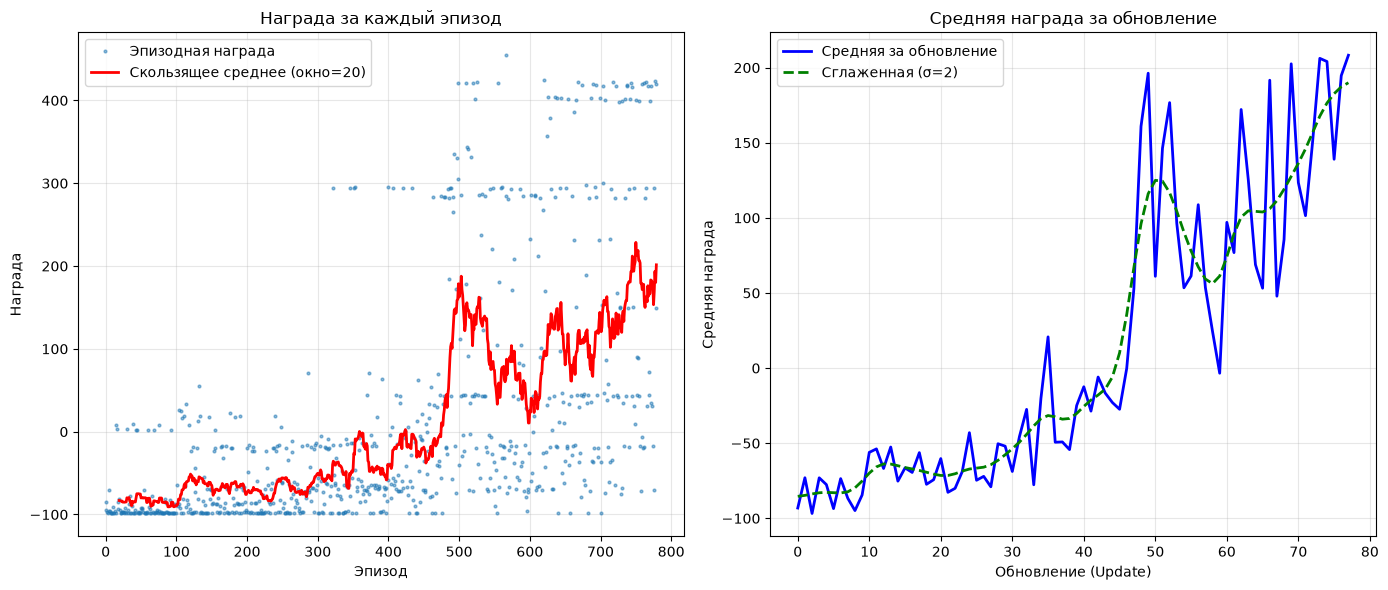

📈 Всего эпизодов: 780
📈 Всего обновлений: 78
📊 Максимальная награда за эпизод: 454.55
📊 Средняя награда за последние 10 эпизодов: 208.25


In [13]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from scipy.ndimage import gaussian_filter1d  # для сглаживания

# Загрузка истории
history_path = os.path.join(MODULE_PATH, "rewards_history.pkl")
if os.path.exists(history_path):
    with open(history_path, "rb") as f:
        data = pickle.load(f)
    episode_rewards = data["episode_rewards"]
    update_rewards = data["update_rewards"]
    
    # ---- График наград по эпизодам ----
    plt.figure(figsize=(14, 6))
    
    # 1. Точки для каждого эпизода
    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards, 'o', markersize=2, alpha=0.5, label='Эпизодная награда')
    
    # 2. Скользящее среднее (окно 20)
    window = 20
    if len(episode_rewards) >= window:
        smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(episode_rewards)), smoothed, 'r-', linewidth=2, label=f'Скользящее среднее (окно={window})')
    
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.title('Награда за каждый эпизод')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Средняя награда за обновление (второй график)
    plt.subplot(1, 2, 2)
    plt.plot(update_rewards, 'b-', linewidth=2, label='Средняя за обновление')
    # тоже сгладим
    if len(update_rewards) >= 5:
        smoothed_update = gaussian_filter1d(update_rewards, sigma=2)
        plt.plot(smoothed_update, 'g--', linewidth=2, label='Сглаженная (σ=2)')
    plt.xlabel('Обновление (Update)')
    plt.ylabel('Средняя награда')
    plt.title('Средняя награда за обновление')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод статистики
    print(f"📈 Всего эпизодов: {len(episode_rewards)}")
    print(f"📈 Всего обновлений: {len(update_rewards)}")
    print(f"📊 Максимальная награда за эпизод: {max(episode_rewards):.2f}")
    print(f"📊 Средняя награда за последние 10 эпизодов: {np.mean(episode_rewards[-10:]):.2f}")
else:
    print("⚠️ Файл истории rewards_history.pkl не найден. Запустите обучение сначала.")

In [18]:
def test_agent():
    ENV_ID = "sguschonka-racing-v0"
    CHECKPOINT_DIR = os.path.join(MODULE_PATH, "models/")
    MAX_EPISODES = 5
    
    actor = tf.keras.models.load_model(os.path.join(CHECKPOINT_DIR, "actor.keras"))
    env = gym.make(ENV_ID, render_mode="human")
    
    for episode in range(MAX_EPISODES):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        step = 0
        while not done and step < 5000:
            mean, _ = actor(tf.convert_to_tensor(obs[None, :], dtype=tf.float32))
            action = mean.numpy()[0]
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            step += 1
            env.render()
        print(f"Эпизод {episode+1}: награда = {total_reward:.2f}")
    env.close()

if MODE in ["test", "both"]:
    print("🎯 ЗАПУСК ТЕСТИРОВАНИЯ")
    test_agent()

🎯 ЗАПУСК ТЕСТИРОВАНИЯ
Эпизод 1: награда = 279.67
Эпизод 2: награда = 415.87
Эпизод 3: награда = 40.55
Эпизод 4: награда = 291.57
Эпизод 5: награда = 40.55


In [19]:
# Просмотр результатов
best_reward_path = os.path.join(MODULE_PATH, "best_reward.txt")
if os.path.exists(best_reward_path):
    with open(best_reward_path, "r") as f:
        print(f"🏆 Лучшая награда: {float(f.read().strip()):.2f}")

🏆 Лучшая награда: 208.25
